# Multilayer Perceptron -- Dry Bean (BOMBAY vs Other) and CCPP Regression

This notebook demonstrates the multilayer perceptron (MLP) on two tasks built from real
data:

- **Classification:** UCI Dry Bean dataset reduced to a binary label -- "BOMBAY" (the
  largest, most distinctive bean variety) vs. "other" (the six smaller varieties combined).
  The MLPClassifier in `mlpackage` is binary-only, so the seven varieties are collapsed.
- **Regression:** UCI Combined Cycle Power Plant -- predict net electrical output from four
  ambient measurements. The target is standardised so that gradient magnitudes stay
  numerically stable during backpropagation.

## Mathematical Intuition

### Forward Pass

For an input $\mathbf{x}$, layer $\ell$ computes:

$$\mathbf{z}^{(\ell)} = W^{(\ell)} \mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)},
\qquad \mathbf{a}^{(\ell)} = \sigma(\mathbf{z}^{(\ell)})$$

with $\mathbf{a}^{(0)} = \mathbf{x}$. Hidden layers use ReLU activation:
$\sigma(z) = \max(0, z)$. The output layer uses sigmoid for binary classification or linear
activation for regression.

### Backpropagation

Define $\delta^{(L)} = \nabla_{a^{(L)}} L \odot \sigma'(z^{(L)})$ at the output layer.
The chain rule propagates errors backward:

$$\delta^{(\ell)} = \left( W^{(\ell+1)} \right)^\top \delta^{(\ell+1)} \odot \sigma'(z^{(\ell)})$$

Weight gradients: $\nabla_{W^{(\ell)}} L = \delta^{(\ell)} \left( a^{(\ell-1)} \right)^\top$.
Updates use gradient descent: $W^{(\ell)} \leftarrow W^{(\ell)} - \eta \, \nabla_{W^{(\ell)}} L$.

## Dataset Overview

| Task | Dataset | Samples | Features | Target |
|---|---|---|---|---|
| Classification | UCI Dry Bean (`fetch_ucirepo(id=602)`) | 13,611 | 16 | Binary: BOMBAY (1) vs other (0) |
| Regression | UCI CCPP (`fetch_ucirepo(id=294)`) | 9,568 | 4 | Net electrical output PE in MW |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo

from mlpackage import (
    MLPClassifier, MLPRegressor,
    StandardScaler, train_test_split,
    classification_report, confusion_matrix,
    r2_score, mean_squared_error,
)

# -------- Classification: Dry Bean (binary collapse: BOMBAY vs Other) --------
bean      = fetch_ucirepo(id=602)
X_bean    = bean.data.features.values.astype(float)
y_str     = bean.data.targets.iloc[:, 0].values
y_bin     = (y_str == "BOMBAY").astype(int)

# -------- Regression: CCPP --------
ccpp      = fetch_ucirepo(id=294)
X_ccpp    = ccpp.data.features.values.astype(float)
y_ccpp    = ccpp.data.targets.values.ravel().astype(float)

print(f"Bean shape : {X_bean.shape}  | binary class counts = {dict(zip(*np.unique(y_bin, return_counts=True)))}")
print(f"CCPP shape : {X_ccpp.shape} | target range = [{y_ccpp.min():.2f}, {y_ccpp.max():.2f}]")

Bean shape : (13611, 16)  | binary class counts = {np.int64(0): np.int64(13089), np.int64(1): np.int64(522)}
CCPP shape : (9568, 4) | target range = [420.26, 495.76]


## Exploratory Data Analysis

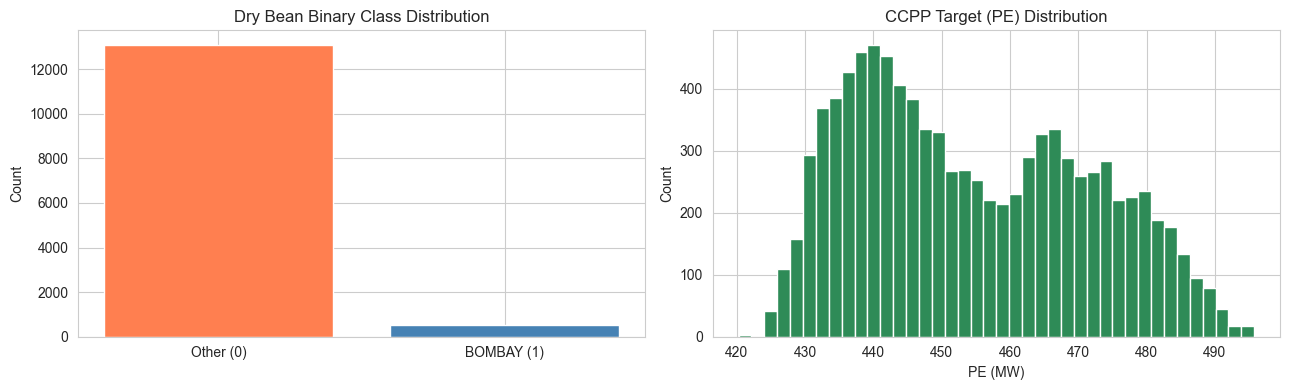

In [2]:
# Bean binary balance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bin_counts = np.bincount(y_bin)
axes[0].bar(["Other (0)", "BOMBAY (1)"], bin_counts, color=["coral", "steelblue"])
axes[0].set_title("Dry Bean Binary Class Distribution")
axes[0].set_ylabel("Count")

# CCPP target distribution
axes[1].hist(y_ccpp, bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("CCPP Target (PE) Distribution")
axes[1].set_xlabel("PE (MW)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

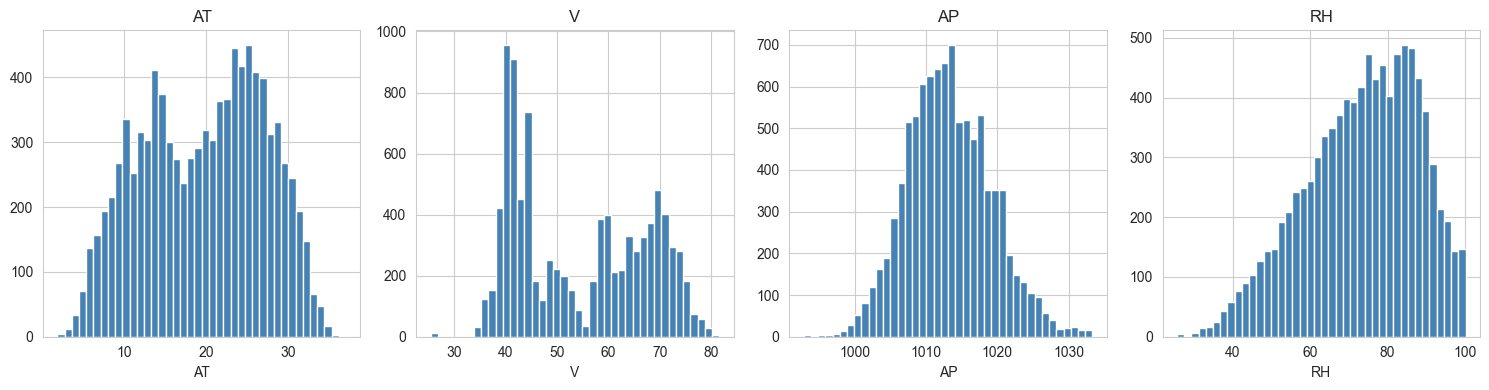

In [3]:
# CCPP feature distributions
ccpp_feat_names = list(ccpp.data.features.columns)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, name in enumerate(ccpp_feat_names):
    axes[i].hist(X_ccpp[:, i], bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(name)
    axes[i].set_xlabel(name)
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
# --- Bean: standardise features ---
X_bean_tr, X_bean_te, y_bean_tr, y_bean_te = train_test_split(
    X_bean, y_bin, test_size=0.2, random_state=42
)
scaler_bean    = StandardScaler()
X_bean_tr_s    = scaler_bean.fit_transform(X_bean_tr)
X_bean_te_s    = scaler_bean.transform(X_bean_te)

# --- CCPP: standardise BOTH features and target (target scaling prevents NaN gradients) ---
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_ccpp, y_ccpp, test_size=0.2, random_state=42
)
scaler_X_cc   = StandardScaler()
X_cc_tr_s     = scaler_X_cc.fit_transform(X_cc_tr)
X_cc_te_s     = scaler_X_cc.transform(X_cc_te)

scaler_y_cc   = StandardScaler()
y_cc_tr_s     = scaler_y_cc.fit_transform(y_cc_tr.reshape(-1, 1)).ravel()
y_cc_te_s     = scaler_y_cc.transform(y_cc_te.reshape(-1, 1)).ravel()

print(f"Classification -- Train: {X_bean_tr_s.shape[0]}  Test: {X_bean_te_s.shape[0]}")
print(f"Regression     -- Train: {X_cc_tr_s.shape[0]}   Test: {X_cc_te_s.shape[0]}")

Classification -- Train: 10888  Test: 2723
Regression     -- Train: 7654   Test: 1914


## Classification (Binary Dry Bean: BOMBAY vs Other)

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    learning_rate=0.05,
    n_iterations=400,
    random_state=42,
)
mlp.fit(X_bean_tr_s, y_bean_tr)

train_acc = mlp.score(X_bean_tr_s, y_bean_tr)
test_acc  = mlp.score(X_bean_te_s, y_bean_te)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}\n")

y_pred = mlp.predict(X_bean_te_s)
classification_report(y_bean_te, y_pred)

Train accuracy: 0.9996  |  Test accuracy: 1.0000

   class   precision      recall    f1-score   support
------------------------------------------------------
       0        1.00        1.00        1.00      2619
       1        1.00        1.00        1.00       104
------------------------------------------------------
weighted avg        1.00        1.00        1.00      2723


Architecture (32,)                Train: 0.9992  |  Test: 0.9996
Architecture (64, 32)             Train: 0.9996  |  Test: 1.0000
Architecture (128, 64, 32)        Train: 0.9999  |  Test: 1.0000


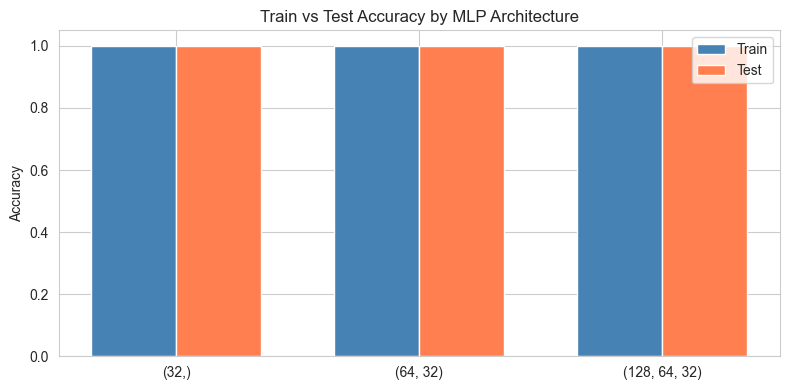

In [6]:
# Architecture sweep
archs = [(32,), (64, 32), (128, 64, 32)]
arch_train, arch_test = [], []
for arch in archs:
    m = MLPClassifier(
        hidden_layer_sizes=arch, learning_rate=0.05,
        n_iterations=400, random_state=42,
    ).fit(X_bean_tr_s, y_bean_tr)
    tr = m.score(X_bean_tr_s, y_bean_tr)
    te = m.score(X_bean_te_s, y_bean_te)
    arch_train.append(tr)
    arch_test.append(te)
    print(f"Architecture {str(arch):20s} Train: {tr:.4f}  |  Test: {te:.4f}")

x = np.arange(len(archs))
w = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, arch_train, w, label="Train", color="steelblue")
plt.bar(x + w/2, arch_test,  w, label="Test",  color="coral")
plt.xticks(x, [str(a) for a in archs])
plt.title("Train vs Test Accuracy by MLP Architecture")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Visualizations (Classification)

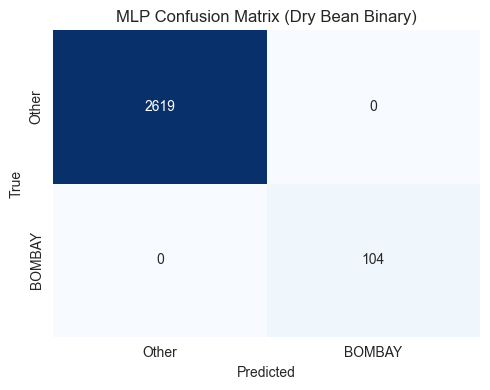

In [7]:
cm = confusion_matrix(y_bean_te, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Other", "BOMBAY"],
            yticklabels=["Other", "BOMBAY"], cbar=False)
plt.title("MLP Confusion Matrix (Dry Bean Binary)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Regression (CCPP, target standardised)

In [8]:
reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    learning_rate=0.01,
    n_iterations=2000,
    random_state=42,
)
reg.fit(X_cc_tr_s, y_cc_tr_s)

# Predict in standardised space, then inverse-transform back to MW
y_pred_tr_s = reg.predict(X_cc_tr_s)
y_pred_te_s = reg.predict(X_cc_te_s)
y_pred_tr   = scaler_y_cc.inverse_transform(y_pred_tr_s.reshape(-1, 1)).ravel()
y_pred_te   = scaler_y_cc.inverse_transform(y_pred_te_s.reshape(-1, 1)).ravel()

train_r2  = r2_score(y_cc_tr, y_pred_tr)
test_r2   = r2_score(y_cc_te, y_pred_te)
test_mse  = mean_squared_error(y_cc_te, y_pred_te)
print(f"Train R2: {train_r2:.4f}  |  Test R2: {test_r2:.4f}  |  Test MSE: {test_mse:.4f}")

Train R2: 0.9357  |  Test R2: 0.9382  |  Test MSE: 17.9688


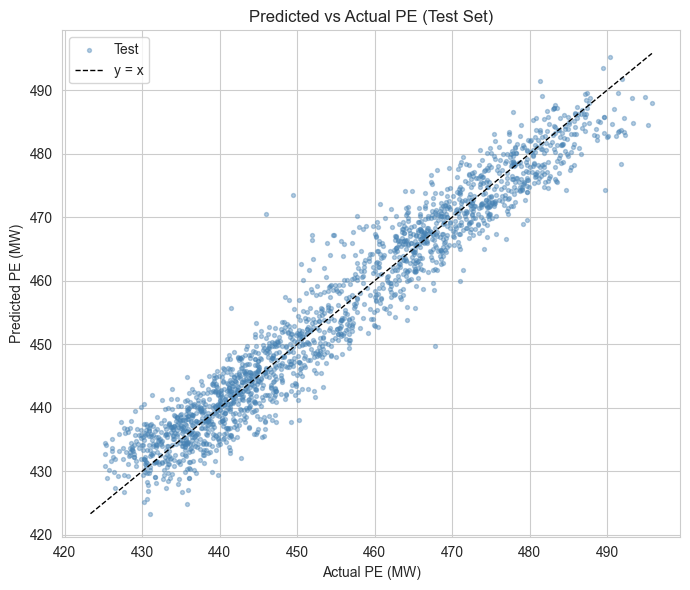

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_cc_te, y_pred_te, alpha=0.4, s=8, color="steelblue", label="Test")
m, M = min(y_cc_te.min(), y_pred_te.min()), max(y_cc_te.max(), y_pred_te.max())
plt.plot([m, M], [m, M], "k--", linewidth=1, label="y = x")
plt.title("Predicted vs Actual PE (Test Set)")
plt.xlabel("Actual PE (MW)")
plt.ylabel("Predicted PE (MW)")
plt.legend()
plt.tight_layout()
plt.show()

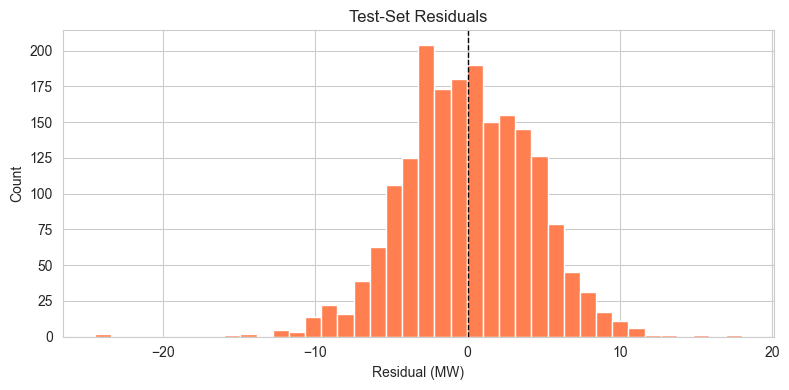

Residual mean: 0.0151  |  Residual std: 4.2389


In [10]:
# Residual histogram
resid = y_cc_te - y_pred_te
plt.figure(figsize=(8, 4))
plt.hist(resid, bins=40, color="coral", edgecolor="white")
plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Test-Set Residuals")
plt.xlabel("Residual (MW)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(f"Residual mean: {resid.mean():.4f}  |  Residual std: {resid.std():.4f}")

## Interpretation and Conclusions

_Analysis to be completed after running the notebook end-to-end._